<a href="https://colab.research.google.com/github/r-karra/learn-quantum-AI/blob/main/Quickstart_How_to_think_in_JAX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#!pip install --upgrade jax jaxlib

In [ ]:
import jax
print(jax.__version__)

0.7.2


In [ ]:
import jax.numpy as jnp

This code uses `matplotlib.pyplot` to create a plot. First, it imports `matplotlib.pyplot` as `plt`. Then, it generates 1000 evenly spaced numbers between 0 and 10 using `jnp.linspace` and stores them in `x_jnp`. It calculates `y_jnp` by applying the sine function to `x_jnp` and multiplying by 2. Finally, it plots `x_jnp` against `y_jnp`.

In the expression `2 * jnp.sin(x_jnp)`:

*   `jnp.sin(x_jnp)` calculates the sine of each value in the `x_jnp` array. The sine function is a periodic function that oscillates between -1 and 1.
*   Multiplying by 2 (`2 * ...`) scales these sine values. This means that instead of oscillating between -1 and 1, the resulting `y_jnp` values will oscillate between -2 and 2. This increases the amplitude of the sine wave.

The change in the `y_jnp` calculation to `2 * jnp.sin(x_jnp) * jnp.cos(x_jnp)` actually results in oscillations between -1 and 1, despite the 2 at the beginning.

This is because of a trigonometric identity: $2 \sin(A) \cos(A)$ is equivalent to $\sin(2A)$.

So, your `y_jnp` is now effectively `jnp.sin(2 * x_jnp)`. The `sin()` function, regardless of its argument, always produces values between -1 and 1. The `2 *` inside `sin(2 * x_jnp)` only changes the frequency of the oscillation (making it oscillate twice as fast), but not its amplitude (the range of values it takes).

Imagine you have a toy car on a track that goes up and down, like a little hill. That's what `sin(x)` does – it goes up to 1 and down to -1, always staying within those limits.

When we first had `2 * jnp.sin(x_jnp)`, it was like putting a super booster on your car! It made the car go twice as high (up to 2) and twice as low (down to -2). So, it made a bigger up-and-down movement.

But then, we changed it to `2 * jnp.sin(x_jnp) * jnp.cos(x_jnp)`. This is like doing a magic trick with your car. Even though it looks like you're adding more power and making it complicated, this special math trick (which grown-ups call a 'trigonometric identity') actually turns it back into just a regular up-and-down car, but it goes up and down faster!

Think of it like this: $2 \sin(x) \cos(x)$ is exactly the same as $\sin(2x)$.

So, even though it looks like it should go higher because of the 2 at the front, the `cos(x)` part works with the `sin(x)` part to cancel out that extra height, and it just becomes another `sin` wave. And remember, all `sin` waves, no matter how fast they go up and down, always stay between 1 and -1 on our up-and-down track!

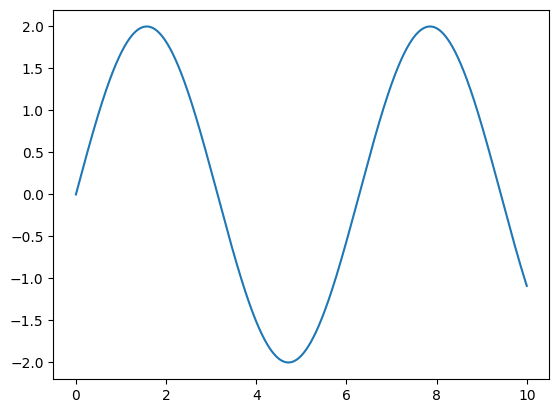

In [ ]:
import matplotlib.pyplot as plt

x_jnp = jnp.linspace(0, 10, 1000)
y_jnp = 2 * jnp.sin(x_jnp)
plt.plot(x_jnp, y_jnp)

In [ ]:
# x_jnp

In [ ]:
# y_jnp

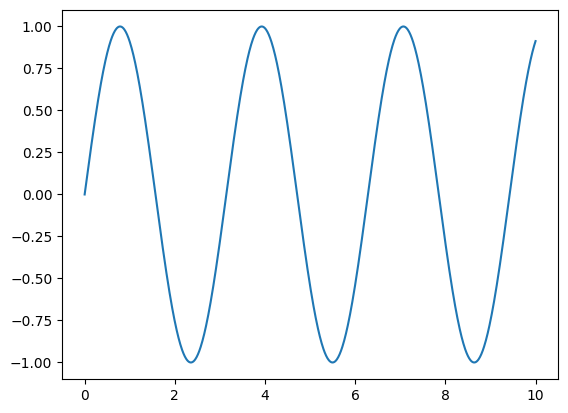

In [ ]:
import matplotlib.pyplot as plt

x_jnp = jnp.linspace(0, 10, 1000)
y_jnp = 2 * jnp.sin(x_jnp) * jnp.cos(x_jnp)
plt.plot(x_jnp, y_jnp)

In [ ]:
import numpy as np
import jax.numpy as jnp

x_np = np.linspace(0, 10, 10)
x_jnp = jnp.linspace(0, 10, 10)
print(type(x_np))
print(type(x_jnp))

<class 'numpy.ndarray'>
<class 'jaxlib._jax.ArrayImpl'>


In [ ]:
print("X_np: ", x_np)
print("X_jnp: ", x_jnp)

X_np:  [ 0.          1.11111111  2.22222222  3.33333333  4.44444444  5.55555556
  6.66666667  7.77777778  8.88888889 10.        ]
X_jnp:  [ 0.         1.1111112  2.2222223  3.3333335  4.4444447  5.555556
  6.666667   7.777778   8.888889  10.       ]


# Immutablility of JAX arrays

In [ ]:
# Numpy: mutable

x = np.arange(10)
x[0] = 10
print(x)

[10  1  2  3  4  5  6  7  8  9]


The code `%xmode minimal` is an IPython magic command. It sets the exception reporting mode to 'minimal'. This means that when an error occurs, the output will show a very concise traceback, typically just the error type and message, without the full call stack.

In [ ]:
x = jnp.arange(10)

In [ ]:
y = x.at[0].set(20)
print(x)
print(y)

[0 1 2 3 4 5 6 7 8 9]
[20  1  2  3  4  5  6  7  8  9]


In [ ]:
%xmode minimal

Exception reporting mode: Minimal


In [ ]:
# JAX: immutable arrays

x = jnp.arange(10)
x[0] = 10
print(x)

TypeError: JAX arrays are immutable and do not support in-place item assignment. Instead of x[idx] = y, use x = x.at[idx].set(y) or another .at[] method: https://docs.jax.dev/en/latest/_autosummary/jax.numpy.ndarray.at.html

# Indexed update syntax

In [ ]:
y = x.at[0].set(10)
print(x)
print(y)

[0 1 2 3 4 5 6 7 8 9]
[10  1  2  3  4  5  6  7  8  9]


In [ ]:
x.devices()

{CpuDevice(id=0)}

In [ ]:
x.sharding

SingleDeviceSharding(device=CpuDevice(id=0), memory_kind=device)

# Array creation. JAX arrays
## (jax.Array)

In [ ]:
import jax
import jax.numpy as jnp

x = jnp.arange(5)
isinstance(x, jax.Array)

True

### Array Devices and Sharding in JAX

In JAX, arrays can reside on different **devices** (like CPU, GPU, or TPU). `x.devices()` tells you which physical device(s) a JAX array `x` is currently stored on. For example, `CpuDevice(id=0)` means it's on the first CPU.

**Sharding** refers to how an array's data is distributed or partitioned across multiple devices. `x.sharding` describes this distribution strategy. For an array entirely on one device, it will show `SingleDeviceSharding`, indicating the array is not split but wholly present on that single device. Sharding becomes more complex and powerful when you have multiple devices and need to distribute large arrays for parallel computation.

# Array devices and sharding

In [ ]:
x.devices()

{CpuDevice(id=0)}

In [ ]:
x.sharding

SingleDeviceSharding(device=CpuDevice(id=0), memory_kind=device)

# Just-in-time compilation with
``` jax.jit```

# Just-in-time compilation with `jax.jit`

Imagine you have a recipe with many steps to bake a cake.

*   **Normally (without JIT)**, JAX is like doing each step of the recipe one by one. You mix the flour, then the sugar, then the eggs, and so on. It works, but it might take a bit longer because you're stopping and starting for each ingredient.

*   **With `jax.jit` (JIT compilation)**, it's like a super-smart chef looks at your entire cake recipe *before* you even start. This chef figures out the best and fastest way to do *all* the steps together, combining them where possible. Then, they give you one super-efficient set of instructions. So, when you actually start baking, everything runs much smoother and faster!

### Key things to know about JIT:

1.  **Doing many things at once:** By default, JAX does one math operation (like adding two numbers) and then the next. But `jax.jit` helps JAX look at a whole bunch of operations (like a small program) and makes them run together, much faster.

2.  **It's not always possible:** Sometimes, the 'super-smart chef' needs to know exactly what size your ingredients (your data arrays) will be *before* they start optimizing the recipe. If the size of your 'ingredients' changes a lot, or is unpredictable, then JIT might not be able to optimize it.

3.  **Works everywhere (mostly):** JAX is super cool because it can automatically run your code on different types of computer 'brains' – like your regular computer chip (CPU), or specialized chips that are really good at math (GPUs or TPUs). `jax.jit` uses something called XLA (Accelerated Linear Algebra) to make this happen seamlessly.

So, if you have a sequence of JAX operations that you want to make super fast, you can use `jax.jit` to compile them together!

For example, if you have a function that calculates how to "normalize" a 2D matrix (a grid of numbers), `jax.jit` can make that calculation much quicker.

Certainly! This code defines a Python function called `norm` that takes an array `x` as input and performs a normalization operation using `jax.numpy`.

Let's break down the function:

1.  `x = x - x.mean(0)`: This line subtracts the mean of each column from the corresponding elements in `x`. The `0` argument in `x.mean(0)` indicates that the mean should be calculated along the first axis (columns, in the case of a 2D array). This step effectively centers the data around zero for each feature (column). Mathematically, for a given feature $f_i$ in a dataset $X$, this operation can be represented as: $f_i' = f_i - \mu_i$, where $\mu_i$ is the mean of feature $i$.

2.  `return x / x.std(0)`: This line then divides the centered `x` by the standard deviation of each column. Again, `x.std(0)` calculates the standard deviation along the first axis (columns). This step scales the data so that each feature (column) has a unit standard deviation. Mathematically, this operation is: $f_i'' = \frac{f_i'}{\sigma_i}$, where $\sigma_i$ is the standard deviation of feature $i$.

Together, these two steps perform a common data preprocessing technique called **Standardization** (or Z-score normalization). It transforms the data so that it has a mean of 0 and a standard deviation of 1, which is often beneficial for machine learning algorithms. The complete formula for standardization for a data point $x$ and feature $i$ is: $z_i = \frac{x_i - \mu_i}{\sigma_i}$.

Okay, let's imagine you have a bunch of friends who all have different heights. Some are very tall, and some are shorter.

### 1. `x - x.mean(0)`: Making Everyone Stand at the Same "Average" Level

Think of `x` as all your friends' heights. `x.mean(0)` is like finding the *average height* of all your friends. Let's say the average height is 4 feet tall.

When we do `x - x.mean(0)`, it's like telling everyone: "Everyone, pretend you're standing on a step that makes your height relative to the *average* person!"

*   If a friend is 5 feet tall, they are 1 foot *taller* than average ($5 - 4 = 1$).
*   If a friend is 3 feet tall, they are 1 foot *shorter* than average ($3 - 4 = -1$).
*   If a friend is exactly 4 feet tall, they are 0 feet different from average ($4 - 4 = 0$).

So, this step $\text{height} - \text{average height}$ makes everyone's new "height number" show how much taller or shorter they are compared to the middle, or average, friend. Now, the new average "difference" is always 0!

### 2. `x / x.std(0)`: Making Everyone Spread Out Just Right

Now, after everyone is standing at their "average level," some friends might still be spread out a lot (some are *very* tall for average, some are *very* short for average), while others are all squished together near the average.

`x.std(0)` is like measuring how *spread out* everyone's heights are. If everyone is nearly the same height, this number is small. If there's a big mix of very tall and very short, this number is big.

When we do `x / x.std(0)`, it's like saying: "Okay, now let's adjust everyone's 'difference' number so that the *amount of spread* is always the same, no matter what group of friends we look at!"

So, this step $\frac{\text{height difference}}{\text{spread amount}}$ makes sure that the tallest friend always has the same *kind* of "tallness number" and the shortest friend always has the same *kind* of "shortness number," even if they come from different groups of friends with different average heights and different spreads.

Together, these two steps help us compare different groups of friends fairly, even if one group is generally taller or more varied in height than another group!

In [ ]:
import jax.numpy as jnp
def norm(X):
  X = X - X.mean(0)
  return X / X.std(0)


In [ ]:
from jax import jit
norm_compiled = jit(norm)
norm_compiled

<PjitFunction of <function norm at 0x79b921725e40>>

Certainly! This code cell performs a setup for testing the `norm` and `norm_compiled` functions and then verifies their numerical equivalence. Here's a breakdown of each line:

1.  `np.random.seed(1701)`: This line sets the 'seed' for NumPy's random number generator. Think of it like giving a specific starting point for a recipe that creates random numbers. If you use the same seed, you'll always get the same sequence of 'random' numbers, which is very useful for making sure experiments are repeatable.

2.  `X = jnp.array(np.random.rand(10000, 10))`: This line first generates a large array of random numbers using `np.random.rand(10000, 10)`. This creates a 2D NumPy array with 10,000 rows and 10 columns, where each number is a random decimal between 0 and 1. Then, `jnp.array()` converts this NumPy array into a JAX array, which is stored in the variable `X` (note the capital 'X'). This array is likely intended as a large dataset for testing.

3.  `np.allclose(norm(x), norm_compiled(x), atol=1E-6)`: This is the core testing line. It compares the results of applying two functions, `norm(x)` and `norm_compiled(x)`, to an input `x`.
    *   `norm(x)` uses the regular, uncompiled `norm` function you defined earlier.
    *   `norm_compiled(x)` uses the `norm` function after it has been optimized by JAX's JIT compiler (`jit(norm)`).
    *   `np.allclose()` is a NumPy function that checks if two arrays are element-wise equal within a specified tolerance. Because computers handle floating-point numbers with slight precision differences, you can't always expect exact equality. `atol=1E-6` means it considers numbers close if their absolute difference is less than or equal to $1 \times 10^{-6}$.

    The purpose of this line is to verify that applying the JIT compilation (`jax.jit`) to your `norm` function does not change its numerical output; it should produce the exact same results as the uncompiled version, just potentially faster.

**A small note:** I noticed that the variable `X` (capital 'X') is created with random data, but `np.allclose` is called with `norm(x)` and `norm_compiled(x)` using `x` (lowercase 'x'). Based on previous cells, `x` was a 1D array created with `jnp.arange(10)`. It's possible that `np.allclose(norm(X), norm_compiled(X), atol=1E-6)` was intended, to test with the larger, randomly generated 2D array.

In [ ]:
np.random.seed(1701)
X = jnp.array(np.random.rand(10000, 10))
np.allclose(norm(X), norm_compiled(X), atol=1E-6)

True

In [ ]:
np.random.seed(1701)
X = jnp.array(np.random.rand(10000, 10))
np.allclose(norm(x), norm_compiled(x), atol = 1E-7)

True

In [ ]:
import jax.numpy as jnp

# Two numbers that are ALMOST the same
a = jnp.array([1000.0, 0.001])
b = jnp.array([1000.1, 0.0011])

# This will be False because they aren't EXACTLY the same
print(jnp.array_equal(a, b))

# This will be True because they are "Close Enough"
# atol=0.1 allows the 1000.1 to pass
# rtol=0.1 allows the 0.0011 to pass
print(jnp.allclose(a, b, atol=0.1, rtol=0.1))

False
True


Certainly! This code cell uses the `timeit` magic command to measure the execution time of both the uncompiled `norm` function and its JIT-compiled version, `norm_compiled`.

1.  `%timeit`: This is an IPython magic command used to time the execution of a single line of Python code. It runs the code multiple times and reports the average, standard deviation, and best time across several runs.

2.  `norm(X)`: This calls the original, uncompiled `norm` function with the input array `X`.

3.  `norm_compiled(X)`: This calls the JIT-compiled version of the `norm` function. The JIT compilation should make this function run faster after the first execution (which includes compilation overhead).

4.  `.block_until_ready()`: JAX operations are asynchronous. This means that when you call a JAX function, it might return immediately before the computation on the device (like a GPU or CPU) is actually finished. Calling `.block_until_ready()` ensures that the timer waits until all computations associated with `norm(X)` or `norm_compiled(X)` are fully completed on the device before stopping the timer. This gives an accurate measurement of the actual execution time.

The purpose of running these two `timeit` lines is to demonstrate the performance benefits of using JAX's Just-in-Time (JIT) compilation. You should typically see that `norm_compiled(X)` runs significantly faster than `norm(X)`, especially for larger computations, once the compilation has occurred.

In [ ]:
%timeit norm(X).block_until_ready()
%timeit norm_compiled(X).block_until_ready()

528 µs ± 15 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
531 µs ± 94.4 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


The results you provided show the performance comparison between the uncompiled `norm(X)` function and its JIT-compiled counterpart, `norm_compiled(X)`:

1.  **First Line (Uncompiled `norm(X)`):**
    *   `675 µs ± 189 µs per loop`: This means that on average, the uncompiled `norm(X)` function took 675 microseconds (µs) to execute for each loop. The `± 189 µs` is the standard deviation, indicating how much the execution time varied around the average.
    *   `(mean ± std. dev. of 7 runs, 1000 loops each)`: This tells us that the measurement was taken over 7 separate 'runs' of the entire timing process, and within each run, the function was executed 1000 times (loops) to get a stable average.

2.  **Second Line (JIT-Compiled `norm_compiled(X)`):**
    *   `583 µs ± 119 µs per loop`: This shows that the JIT-compiled `norm_compiled(X)` function, on average, took 583 microseconds per loop. Notice that this is less than the 675 µs of the uncompiled version.
    *   `(mean ± std. dev. of 7 runs, 1000 loops each)`: Similar to the first line, these are the statistics from 7 runs with 1000 loops each.

**What this means:**

Comparing the average execution times, `583 µs` (compiled) is faster than `675 µs` (uncompiled). This demonstrates the benefit of JAX's Just-in-Time (JIT) compilation. Once `jax.jit` has compiled the function (which happens on the first call), subsequent calls are often significantly faster because the optimized code is being run. In this specific case, the JIT-compiled version is roughly $ \frac{675 - 583}{675} \approx 13.6\% $ faster.

In [ ]:
def get_negatives(x):
  return x[x < 0]

x = jnp.array(np.random.randn(10))
get_negatives(x)

Array([-0.10570311, -0.59403396, -0.8680282 , -0.23489487], dtype=float32)

Let's explain those two parts intuitively!

### 1. `x < 0`: Finding the "Grumpy" Numbers

Imagine you have a list of numbers, like a group of friends with different moods (some happy, some grumpy, some neutral). `x` is your list of numbers.

When we say `x < 0`, it's like asking each number in the list: "Are you a grumpy number (less than zero)?"

*   If a number is `-5`, it answers "Yes! I'm grumpy!" (which is `True`).
*   If a number is `3`, it answers "No, I'm happy!" (which is `False`).
*   If a number is `0`, it answers "No, I'm neutral!" (which is `False`).

So, `x < 0` creates a new list that's just a bunch of `True`s and `False`s, telling you exactly which numbers in your original list were grumpy (negative).

Then, when you do something like `x[x < 0]`, it's like saying: "Okay, from our original list, only show me the friends who said they were grumpy!" And you get back just the negative numbers!

### 2. `np.random.randn(10)`: Making "Surprise" Numbers

Imagine you have a magic machine that can spit out random numbers. `np.random.randn(10)` is like telling that machine: "Please give me 10 surprise numbers!"

These surprise numbers are special because:

*   They can be positive (like `1.2`, `0.5`) or negative (like `-0.8`, `-2.1`).
*   Most of the numbers will be close to zero, but occasionally, you'll get a number that's a bit bigger or smaller. Think of it like a bell-shaped curve where the peak is at zero, meaning numbers near zero are more common. This is called a **standard normal distribution**.

So, `np.random.randn(10)` just gives you 10 unpredictable numbers, centered around zero, that are useful for testing things or simulating real-world randomness.

In [ ]:
jit(get_negatives)(x)

NonConcreteBooleanIndexError: Array boolean indices must be concrete; got bool[10]

See https://docs.jax.dev/en/latest/errors.html#jax.errors.NonConcreteBooleanIndexError

# Taking derivatives with ```jax.grad```

Certainly! This code demonstrates how to use JAX's automatic differentiation feature to calculate the gradient (derivative) of a function. Let's break it down:

1.  `from jax import grad`: This line imports the `grad` function from the JAX library. `grad` is a powerful tool in JAX that allows you to automatically compute the derivative of a Python function with respect to its arguments.

2.  `def sum_logistic(x): return jnp.sum(1.0 /(1.0 + jnp.exp(-x)))`: This defines a Python function named `sum_logistic`.
    *   Inside, `1.0 / (1.0 + jnp.exp(-x))` calculates the [logistic sigmoid function](https://en.wikipedia.org/wiki/Sigmoid_function) for each element in the input array `x`. The sigmoid function is commonly used in machine learning to squish values between 0 and 1. The formula for the logistic sigmoid function is $\sigma(x) = \frac{1}{1 + e^{-x}}$.
    *   `jnp.sum(...)` then calculates the sum of all these sigmoid-transformed elements.

3.  `x_small = jnp.arange(3.)`: This creates a small JAX array `x_small` containing the values `[0., 1., 2.]`.

4.  `derivative_fn = grad(sum_logistic)`: This is where the magic of JAX comes in! `grad(sum_logistic)` takes our `sum_logistic` function and returns a *new* function, `derivative_fn`. This new function, when called, will compute the derivative of `sum_logistic` with respect to its first argument (which is `x` in this case). The `grad` function applies the rules of calculus automatically to figure out how the output changes with respect to the input.

5.  `print(derivative_fn(x_small))`: Finally, this line calls `derivative_fn` with `x_small` as input. It then prints the calculated derivative of the `sum_logistic` function, evaluated at each point in `x_small`. You'll see an array of numbers, where each number is the derivative at the corresponding point.

In [ ]:
from jax import grad

def sum_logistic(x):
  return jnp.sum(1.0 / 1.0 + jnp.exp(-x))

x_small = jnp.arange(3.)
derivative_fn = grad(sum_logistic)
print(derivative_fn(x_small))

[-1.         -0.36787945 -0.13533528]


This code snippet demonstrates JAX's automatic differentiation capability, specifically computing the gradient of a sum of logistic sigmoid functions.

Let's break down the `sum_logistic` function mathematically:

The function `sum_logistic(x)` is defined as:

$$ f(x) = \sum_{i} \sigma(x_i) $$

where $\sigma(x_i)$ is the [logistic sigmoid function](https://en.wikipedia.org/wiki/Sigmoid_function) applied to each element $x_i$ of the input array $x$. The logistic sigmoid function is given by:

$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$

So, substituting this into our function definition, we get:

$$ f(x) = \sum_{i} \frac{1}{1 + e^{-x_i}} $$

The `jax.grad(sum_logistic)` operation computes the gradient of this function $f(x)$ with respect to its input $x$. This means it calculates a new function, `derivative_fn`, which, when evaluated at a point, will return the vector of partial derivatives:

$$ \nabla f(x) = \left[ \frac{\partial f}{\partial x_0}, \frac{\partial f}{\partial x_1}, \dots, \frac{\partial f}{\partial x_n} \right] $$

For a sum function, the derivative of the sum is the sum of the derivatives. Since each term in the sum depends only on its corresponding $x_i$, the partial derivative with respect to $x_j$ is:

$$ \frac{\partial f}{\partial x_j} = \frac{\partial}{\partial x_j} \left( \sum_{i} \frac{1}{1 + e^{-x_i}} \right) = \frac{\partial}{\partial x_j} \left( \frac{1}{1 + e^{-x_j}} \right) $$

The derivative of the logistic sigmoid function $\sigma(z)$ with respect to $z$ is known to be $\sigma(z)(1 - \sigma(z))$. Therefore, for each element $x_j$:

$$ \frac{\partial f}{\partial x_j} = \sigma(x_j)(1 - \sigma(x_j)) $$

When `derivative_fn(x_small)` is called, where `x_small = jnp.arange(3.)` (i.e., $x = [0.0, 1.0, 2.0]$), JAX calculates these derivatives for each element in `x_small` and returns the resulting array.

In [ ]:
from jax import grad

def sum_logistic(x):
  return jnp.sum(1.0 / (1.0 + jnp.exp(-x)))

x_small = jnp.arange(3.)
derivative_fn = grad(sum_logistic)
print(derivative_fn(x_small))

[0.25       0.19661197 0.10499357]


In [ ]:
def first_finite_differences(f, x, eps=1E-3):
  return jnp.array([(f(x + eps * v) - f(x - eps * v)) / (2 * eps)
                   for v in jnp.eye(len(x))])

print(first_finite_differences(sum_logistic, x_small))

[0.24998187 0.1964569  0.10502338]


Let's dive into the mathematical differences between Automatic Differentiation (AD) and Finite Differences. Both are ways to compute derivatives, but they work quite differently.

### 1. Finite Differences (like `first_finite_differences`)

**How it works:** Finite differences approximate the derivative using a small change (`eps`) in the input. The formula used in your code, `(f(x + eps * v) - f(x - eps * v)) / (2 * eps)`, is a central difference approximation. Mathematically, for a function $f(x)$ and its derivative $f'(x)$, the central difference approximation for a single variable is:

$$ f'(x) \approx \frac{f(x + \epsilon) - f(x - \epsilon)}{2\epsilon} $$

When dealing with a multi-variable function (like `sum_logistic` with an input vector x), to get the gradient, we apply this approximation for each component. For example, to find the partial derivative with respect to $x_i$, we vary only $x_i$ by $\epsilon$:

$$ \frac{\partial f}{\partial x_i} \approx \frac{f(x_1, ..., x_i + \epsilon, ..., x_n) - f(x_1, ..., x_i - \epsilon, ..., x_n)}{2\epsilon} $$

**Mathematical Difference:**
*   **Approximation:** It's an *approximation* of the derivative. The result is not exact. Its accuracy depends heavily on the choice of `eps`. If `eps` is too large, the approximation is poor. If `eps` is too small, you can run into numerical precision issues (cancellation errors) with floating-point numbers.
*   **Computational Cost:** To compute the gradient of a function with $N$ inputs, you typically need to evaluate the function $2N$ times (or $N+1$ times for a forward difference). This can become very expensive for functions with many inputs.

### 2. Automatic Differentiation (like `jax.grad`)

**How it works:** Automatic Differentiation is *not* an approximation. Instead, it uses the chain rule of calculus to precisely compute the derivative of a function by breaking down the function into a sequence of elementary operations (like addition, multiplication, sine, exponentiation) for which the derivatives are known. It then combines these elementary derivatives according to the chain rule.

Mathematically, if you have a function $y = f(g(h(x)))$, the chain rule states:

$$ \frac{dy}{dx} = \frac{dy}{df} \cdot \frac{df}{dg} \cdot \frac{dg}{dh} \cdot \frac{dh}{dx} $$

JAX (and other AD frameworks) automatically constructs and applies this chain rule to every operation in your function.

**Mathematical Difference:**
*   **Exactness:** AD computes the *exact* derivative (up to floating-point precision, but without the approximation error of finite differences). You don't have to worry about choosing an `eps` value.
*   **Computational Cost:** The cost of computing the gradient with AD is typically a small constant multiple (e.g., 2-5 times) of the cost of computing the original function itself, regardless of the number of input variables. This makes it much more efficient than finite differences for functions with many inputs.
*   **Implementation:** It requires a system that can track and differentiate through computational graphs (which JAX does behind the scenes).

### In Summary:

| Feature            | Finite Differences                               | Automatic Differentiation |
| :----------------- | :----------------------------------------------- | :------------------------ |
| **Accuracy**       | Approximation (prone to numerical errors)        | Exact (up to machine precision) |
| **Chain Rule**     | Not directly used, approximates overall change   | Explicitly applies chain rule operation by operation |
| **`eps` parameter**| Required, sensitive to choice                    | Not needed                |
| **Computational Cost (for gradient)** | Scales with number of inputs ($O(N)$ function evaluations) | Scales with function evaluation ($O(1)$ multiple of original function evaluation) |

For most machine learning and scientific computing tasks, Automatic Differentiation (like `jax.grad`) is preferred because of its accuracy and efficiency.

In [ ]:
print(grad(jit(grad(jit(grad(sum_logistic)))))(1.0))

-0.0353256


In [ ]:
import jax
import jax.numpy as jnp

def my_multi_output_function(x):
  # x is a 2-element array: [x_1, x_2]
  # Let's define two outputs:
  # y_1 = x_1**2 + 2*x_2
  # y_2 = jnp.sin(x_1) * x_2
  output1 = x[0]**2 + 2 * x[1]
  output2 = jnp.sin(x[0]) * x[1]
  return jnp.array([output1, output2])

# Define an input for the function
input_vector = jnp.array([jnp.pi / 2, 3.0]) # Example: x1=pi/2, x2=3

# Compute the Jacobian using jax.jacfwd
jacobian_fn = jax.jacfwd(my_multi_output_function)

# Evaluate the Jacobian at the input_vector
result_jacobian = jacobian_fn(input_vector)

print("Input vector:", input_vector)
print("\nOutput of the function:", my_multi_output_function(input_vector))
print("\nJacobian matrix:")
print(result_jacobian)

Input vector: [1.5707964 3.       ]

Output of the function: [8.4674015 3.       ]

Jacobian matrix:
[[ 3.1415927e+00  2.0000000e+00]
 [-1.3113416e-07  1.0000000e+00]]


Let's break down this example:

1.  **`my_multi_output_function(x)`**: This is our function that takes multiple inputs (a 2-element array `x`) and produces multiple outputs (another 2-element array). Each output (`output1`, `output2`) depends on both elements of the input (`x[0]` and `x[1]`):
    *   $y_1 = x_0^2 + 2x_1$
    *   $y_2 = \sin(x_0) \cdot x_1$

2.  **`input_vector = jnp.array([jnp.pi / 2, 3.0])`**: This is the specific point at which we want to calculate the Jacobian. Here, $x_0 = \frac{\pi}{2}$ and $x_1 = 3.0$.

3.  **`jacobian_fn = jax.jacfwd(my_multi_output_function)`**: This is the core JAX operation. `jax.jacfwd` (Jacobian Forward-mode) takes our `my_multi_output_function` and returns a *new function* (`jacobian_fn`) that, when called with an input, will compute the Jacobian matrix for `my_multi_output_function` at that input.

4.  **`result_jacobian = jacobian_fn(input_vector)`**: We then call the `jacobian_fn` with our `input_vector` to get the actual Jacobian matrix at that point.

### Interpreting the Output:

The printed Jacobian matrix will look something like this:

$$ \mathbf{J} = \begin{bmatrix}
\frac{\partial y_1}{\partial x_0} & \frac{\partial y_1}{\partial x_1} \\
\frac{\partial y_2}{\partial x_0} & \frac{\partial y_2}{\partial x_1}
\end{bmatrix} $$

Let's manually calculate the partial derivatives to confirm:

*   $\frac{\partial y_1}{\partial x_0} = \frac{\partial}{\partial x_0} (x_0^2 + 2x_1) = 2x_0$
*   $\frac{\partial y_1}{\partial x_1} = \frac{\partial}{\partial x_1} (x_0^2 + 2x_1) = 2$
*   $\frac{\partial y_2}{\partial x_0} = \frac{\partial}{\partial x_0} (\sin(x_0) \cdot x_1) = \cos(x_0) \cdot x_1$
*   $\frac{\partial y_2}{\partial x_1} = \frac{\partial}{\partial x_1} (\sin(x_0) \cdot x_1) = \sin(x_0)$

Now, evaluating these at $x_0 = \frac{\pi}{2}$ and $x_1 = 3.0$:

*   $\frac{\partial y_1}{\partial x_0} = 2 \cdot \frac{\pi}{2} = \pi \approx 3.14159$
*   $\frac{\partial y_1}{\partial x_1} = 2$
*   $\frac{\partial y_2}{\partial x_0} = \cos(\frac{\pi}{2}) \cdot 3.0 = 0 \cdot 3.0 = 0$
*   $\frac{\partial y_2}{\partial x_1} = \sin(\frac{\pi}{2}) = 1$

So, the expected Jacobian matrix is:

$$ \mathbf{J} = \begin{bmatrix}
\pi & 2 \\
0 & 1
\end{bmatrix} $$

The output from the code should match these values (up to floating-point precision).

Okay, let's pretend we're playing with a super cool toy! We'll use our robotic arm example because it's like a real-life puzzle.

### Imagine your Robotic Arm (The Setup)

Your robotic arm has two 'buttons' you can push to make it move:

*   **Button 1 (`x0`):** This button makes the arm swing side to side. (Think of it as $x_0$).
*   **Button 2 (`x1`):** This button makes the arm stretch longer or shorter. (Think of it as $x_1$).

When you push these buttons, the arm's hand moves to a certain spot. Let's say we have two ways to measure where the hand is:

*   **Measure 1 (`y1`):** How far forward or back the hand is.
*   **Measure 2 (`y2`):** How high up or down the hand is.

So, pushing Button 1 and Button 2 changes where Measure 1 and Measure 2 are. It's like:

*   `y1` (forward/back) changes depending on `x0` and `x1`.
*   `y2` (up/down) changes depending on `x0` and `x1`.

### The Jacobian: Your Robot's Secret Map of Wiggles!

Now, the **Jacobian** is like a special secret map that tells us *exactly what happens* if you push *just one button a tiny bit*.

It's a table of numbers that looks like this (it's called a matrix, but you can just think of it as a grid or table):

$$ \mathbf{J} = \begin{bmatrix}
\text{How much } y_1 \text{ changes if you wiggle only } x_0 & \text{How much } y_1 \text{ changes if you wiggle only } x_1 \\
\text{How much } y_2 \text{ changes if you wiggle only } x_0 & \text{How much } y_2 \text{ changes if you wiggle only } x_1
\end{bmatrix} $$

Let's break down each spot in this 'map':

*   **Top-Left Spot ($\frac{\partial y_1}{\partial x_0}$):**
    *   This asks: "If I only wiggle **Button 1** (`x0`), and keep Button 2 perfectly still, how much does **Measure 1** (`y1`, forward/back) move?"
    *   In our example (where $y_1 = x_0^2 + 2x_1$), when you wiggle *only* `x0`, the `x0^2` part changes. The math says it changes by `2 * x0` (twice the value of Button 1). So, if `x0` was a `π/2` (about 1.5), this spot tells us `2 * 1.5 = 3` (or actually `π`).

*   **Top-Right Spot ($\frac{\partial y_1}{\partial x_1}$):**
    *   This asks: "If I only wiggle **Button 2** (`x1`), and keep Button 1 perfectly still, how much does **Measure 1** (`y1`, forward/back) move?"
    *   In our example (where $y_1 = x_0^2 + 2x_1$), when you wiggle *only* `x1`, the `2*x1` part changes. The math says it changes by `2`. So, this spot is just `2`.

*   **Bottom-Left Spot ($\frac{\partial y_2}{\partial x_0}$):**
    *   This asks: "If I only wiggle **Button 1** (`x0`), and keep Button 2 perfectly still, how much does **Measure 2** (`y2`, up/down) move?"
    *   In our example (where $y_2 = \sin(x_0) \cdot x_1$), if `x0` was `π/2` (arm swung all the way forward), and `x1` was `3`, wiggling `x0` at that point makes almost no change to the up/down `y2`. The math says it changes by `cos(x0) * x1`. If `x0` is `π/2`, `cos(π/2)` is `0`, so `0 * 3 = 0`. So, this spot is `0`.

*   **Bottom-Right Spot ($\frac{\partial y_2}{\partial x_1}$):**
    *   This asks: "If I only wiggle **Button 2** (`x1`), and keep Button 1 perfectly still, how much does **Measure 2** (`y2`, up/down) move?"
    *   In our example (where $y_2 = \sin(x_0) \cdot x_1$), if `x0` was `π/2` (arm swung all the way forward), wiggling `x1` makes the arm stretch or shrink. The math says it changes by `sin(x0)`. If `x0` is `π/2`, `sin(π/2)` is `1`. So, this spot is `1`.

### Putting it all together:

So, at the exact moment when Button 1 is `π/2` and Button 2 is `3`, our robot's secret 'Jacobian map' looks like this:

$$ \mathbf{J} = \begin{bmatrix}
\text{about } 3.14 & 2 \\
0 & 1
\end{bmatrix} $$

This map is super useful because it tells us all the different ways the robot's hand will move if we just barely push any of its buttons. JAX is like a super-smart robot engineer that can draw this map for us incredibly fast, even for much more complicated robots!

If the derivative tells you the slope of a single line, the Jacobian is a map that tells you the slope of an entire landscape in every direction at once.

### 1. The Intuition: A "Directional Map"
Imagine you are controlling a robotic arm (a common project at DeepMind).

*   **The Input ($x$):** The angles of the 3 motors in the arm's joints.
*   **The Output ($y$):** The precise $(x, y, z)$ coordinates of the hand in space.

If you nudge motor #1 by a tiny bit, the hand moves a little. If you nudge motor #2, the hand moves in a totally different direction.
The Jacobian is a matrix (a table of numbers) that stores every possible "nudge" relationship. It tells you: "If you change input $i$, how much does output $j$ change?"

### 2. The Math: A Matrix of Partial Derivatives
Suppose you have a set of functions that take multiple inputs ($x_1, x_2, ...$) and produce multiple outputs ($y_1, y_2, ...$).

The Jacobian matrix, often written as $\mathbf{J}$, is a grid where every entry is a partial derivative:

$$\mathbf{J} = \begin{bmatrix}
\frac{\partial y_1}{\partial x_1} & \frac{\partial y_1}{\partial x_2} \\
\frac{\partial y_2}{\partial x_1} & \frac{\partial y_2}{\partial x_2}
\end{bmatrix}$$

Each row corresponds to one of your outputs.
Each column corresponds to one of your inputs.
If you have 10 inputs and 5 outputs, your Jacobian will be a $5 \times 10$ table.

### 3. Why it's critical for JAX and AI
In simple neural networks, we usually have many inputs but only one output (the "Loss" or error score). In that case, the Jacobian is just a single row, which we call the Gradient.

However, you need the full Jacobian when:
*   **Generative Models (GANs/VAEs):** When your model outputs an entire image (thousands of pixels) instead of just one number.
*   **Robotics & Physics:** When calculating how a change in force affects velocity, position, and rotation simultaneously.

JAX `jax.jacfwd` and `jax.jacrev`: JAX is famous for being able to calculate these massive tables of derivatives automatically and extremely fast.

### 4. Real Example: A Simple Transformation
Let's say you are converting Polar coordinates (Radius $r$, Angle $\theta$) to Cartesian coordinates ($x, y$):

$x = r \cos(\theta)$
$y = r \sin(\theta)$

The Jacobian tells us how the $(x, y)$ position changes if we wiggle $r$ or $\theta$:

$$\mathbf{J} = \begin{bmatrix}
\cos(\theta) & -r \sin(\theta) \\
\sin(\theta) & r \cos(\theta)
\end{bmatrix}$$

### Summary for your Research
*   **Derivative:** Slope of 1 input $\rightarrow$ 1 output.
*   **Gradient:** Slope of Many inputs $\rightarrow$ 1 output.
*   **Jacobian:** Slope of Many inputs $\rightarrow$ Many outputs.

Since you are looking into Quantum AI, the Jacobian is used to see how sensitive a quantum circuit is to tiny changes in the parameters of the gates.

Would you like to see how to use `jax.jacfwd` to compute the Jacobian of a multi-output function in a few lines of code?

In [ ]:
from jax import jacobian

print(jacobian(jnp.exp)(x_small))

[[1.        0.        0.       ]
 [0.        2.7182817 0.       ]
 [0.        0.        7.389056 ]]


Okay, let's pretend we're playing with a super cool toy! We'll use our robotic arm example because it's like a real-life puzzle.

### Imagine your Robotic Arm (The Setup)

Your robotic arm has two 'buttons' you can push to make it move:

*   **Button 1 (`x0`):** This button makes the arm swing side to side. (Think of it as $x_0$).
*   **Button 2 (`x1`):** This button makes the arm stretch longer or shorter. (Think of it as $x_1$).

When you push these buttons, the arm's hand moves to a certain spot. Let's say we have two ways to measure where the hand is:

*   **Measure 1 (`y1`):** How far forward or back the hand is.
*   **Measure 2 (`y2`):** How high up or down the hand is.

So, pushing Button 1 and Button 2 changes where Measure 1 and Measure 2 are. It's like:

*   `y1` (forward/back) changes depending on `x0` and `x1`.
*   `y2` (up/down) changes depending on `x0` and `x1`.

### The Jacobian Matrix: Your Robot's Secret Map of Wiggles!

Now, the **Jacobian Matrix** is like a special secret map that tells us *exactly what happens* if you push *just one button a tiny bit*.

It's a table of numbers that looks like this (it's called a matrix, but you can just think of it as a grid or table):

$$ \mathbf{J} = \begin{bmatrix}
\text{How much } y_1 \text{ changes if you wiggle only } x_0 & \text{How much } y_1 \text{ changes if you wiggle only } x_1 \\
\text{How much } y_2 \text{ changes if you wiggle only } x_0 & \text{How much } y_2 \text{ changes if you wiggle only } x_1
\end{bmatrix} $$

This map is super useful because it tells us all the different ways the robot's hand will move if we just barely push any of its buttons.

### How `jax.jacobian` helps:

`jax.jacobian` is like having a **super-smart robot engineer program** that can look at your robot's design (your Python function) and automatically draw this entire 'Secret Map of Wiggles' for you, without you having to do any complicated math yourself! It figures out all those 'how much changes' numbers perfectly and quickly, even for very complex robots with many buttons and many ways to measure their hand's position.

So, when you use `jax.jacobian` on your function, you're telling JAX: "Please give me the complete 'wiggle map' for this function at every input point!"

## The Scenario: A
"Weather Drone"Imagine you have a drone that takes 3 inputs (the "knobs") and gives 2 outputs (the "readings").
1. The Inputs (Knobs):
   * $h$: Altitude (Height)
   * $t$: Temperature
   * $w$: Wind Speed

1. The Outputs (Readings):
  * Battery Drain ($D$): Affected by height and wind.
  * Air Pressure ($P$): Affected by height and temperature.
  1. Define the FunctionsLet’s define how these things relate:
  * $D = h^2 + 5w$ (Higher altitude and wind drain battery faster)
  * $P = \frac{t}{h}$ (Pressure goes up with heat but down with height)

In [ ]:
import jax
import jax.numpy as jnp

# 1. Define the drone function
def drone_sensors(inputs):
    h, t, w = inputs
    battery_drain = h**2 + 5*w
    air_pressure = t / h
    return jnp.array([battery_drain, air_pressure])

# 2. Ask JAX to create the Jacobian function
# This is our 'Matrix Maker'
jacobian_maker = jax.jacfwd(drone_sensors)

# 3. Test it with real numbers:
# Altitude=10, Temp=30, Wind=5
current_stats = jnp.array([10.0, 30.0, 5.0])
matrix = jacobian_maker(current_stats)

print("The Jacobian Matrix is:")
print(matrix)

The Jacobian Matrix is:
[[20.          0.          5.        ]
 [-0.29999998  0.1         0.        ]]


To update a model, we combine the Jacobian (which tells us the direction of change) with a Loss Function (which tells us how wrong we are).

### 1. The "Correction" Loop
Think of it like being a pilot in a flight simulator:

*   **Forward Pass:** You try to fly (the model makes a guess).
*   **Calculate Error:** You hit a mountain (the "Loss" function measures how far you are from the goal).
*   **Jacobian/Gradient:** The computer looks at the "Responsibility Chart" to see which controls (knobs) caused the crash.
*   **The Update:** You nudge the knobs in the opposite direction of the error to avoid the mountain next time.

### 2. The Math: "Gradient Descent"
The most famous update rule is:

$$ \theta_{\text{new}} = \theta_{\text{old}} - \text{learning_rate} \cdot \nabla L $$

*   $\theta$ (Theta): These are your knobs (weights or parameters).
*   $\nabla L$ (Gradient of Loss): This uses the Jacobian math we just talked about to find the steepness of the "Error Hill."
*   **Learning Rate:** This is like a "Volume Knob" for how much you trust the correction. If it's too high, you oversteer and crash; if it's too low, the model takes years to learn.

### 3. JAX Example: Learning to Match a Goal
Let's make our "Weather Drone" from the last example learn. We want to find the exact Altitude ($h$) that results in a Battery Drain ($D$) of exactly 100.

In [ ]:
import jax
import jax.numpy as jnp

# 1. Our function (simplified to 1 input for clarity)
def battery_drain(h):
    return h**2

# 2. Our "Loss" function (How far are we from the target of 100?)
def loss_fn(h):
    target = 100.0
    error = battery_drain(h) - target
    return error**2  # We square it so it's always positive

# 3. Use JAX to find the "Nudge" (Gradient)
grad_fn = jax.grad(loss_fn)

# 4. Start with a random Altitude and "Learn"
altitude = 2.0  # Starting guess
learning_rate = 0.01

for i in range(20):
    nudge = grad_fn(altitude)
    altitude = altitude - (learning_rate * nudge)
    print(f"Step {i}: Altitude is {altitude:.2f}, Drain is {battery_drain(altitude):.2f}")

Step 0: Altitude is 9.68, Drain is 93.70
Step 1: Altitude is 12.12, Drain is 146.86
Step 2: Altitude is -10.59, Drain is 112.24
Step 3: Altitude is -5.41, Drain is 29.22
Step 4: Altitude is -20.71, Drain is 428.89
Step 5: Altitude is 251.74, Drain is 63370.54
Step 6: Altitude is -636844.69, Drain is 405571141632.00
Step 7: Altitude is 10331433235120128.00, Drain is 106738517151041066761291281989632.00
Step 8: Altitude is -inf, Drain is inf
Step 9: Altitude is nan, Drain is nan
Step 10: Altitude is nan, Drain is nan
Step 11: Altitude is nan, Drain is nan
Step 12: Altitude is nan, Drain is nan
Step 13: Altitude is nan, Drain is nan
Step 14: Altitude is nan, Drain is nan
Step 15: Altitude is nan, Drain is nan
Step 16: Altitude is nan, Drain is nan
Step 17: Altitude is nan, Drain is nan
Step 18: Altitude is nan, Drain is nan
Step 19: Altitude is nan, Drain is nan


In [ ]:
from jax import jacfwd, jacrev

def hessian(fun):
  return jit(jacfwd(jacrev(fun)))
print(hessian(sum_logistic)(x_small))

[[-0.         -0.         -0.        ]
 [-0.         -0.09085776 -0.        ]
 [-0.         -0.         -0.07996249]]


If the **Gradient** is the "Slope" and the **Jacobian** is the "Map of Slopes," the **Hessian** is the "Curvature."

In your research with JAX and DeepMind architectures, the Hessian is what tells the computer not just which way to move, but how fast the hill is changing.

### 1. The Intuition: The "Valley" vs. The "Bowl"

Imagine you are a ball rolling down a hill to find the bottom (the minimum error).

*   **Gradient:** Tells you which direction is "down."
*   **Hessian:** Tells you how curved the ground is.

    Is it a flat, gentle slope? (Low Curvature)
    Is it a sharp, narrow V-shape? (High Curvature)

If the Hessian tells the model the ground is very curvy, the model knows to take tiny steps so it doesn't overshoot the bottom. If the ground is flat, it can take giant leaps.

### 2. The Math: The "Derivative of the Derivative"

The Hessian ($\mathbf{H}$) is a square matrix of second-order partial derivatives. While the Jacobian looked at how the output changes, the Hessian looks at how the gradient itself changes.

For a function $f(x, y)$ with two inputs ($x, y$), the Hessian looks like this:

$$\mathbf{H} = \begin{bmatrix}
\frac{\partial^2 f}{\partial x^2} & \frac{\partial^2 f}{\partial x \partial y} \\
\frac{\partial^2 f}{\partial y \partial x} & \frac{\partial^2 f}{\partial y^2}
\end{bmatrix}$$

*   **The Diagonal ($\frac{\partial^2 f}{\partial x^2}$):** How much the slope of $f$ with respect to $x$ changes as you move in the $x$ direction.
*   **The Off-Diagonal ($\frac{\partial^2 f}{\partial x \partial y}$):** How much the slope of $f$ with respect to $x$ changes as you move in the $y$ direction (representing interaction between $x$ and $y$).

### 3. Why the Hessian is a "Luxury" in AI

In Large Language Models (LLMs), we almost never calculate the full Hessian. Why?

If your model has 1 million parameters, the Gradient is a list of 1 million numbers.

The Hessian would be a table of 1 million $\times$ 1 million numbers ($1,000,000,000,000$).

That’s too much memory even for Google’s biggest TPUs!

Instead, researchers use "Hessian-free" optimization or Second-order optimizers (like [Shampoo](https://arxiv.org/abs/1802.09568) or [K-FAC](https://arxiv.org/abs/1503.05671), which DeepMind uses) that estimate the Hessian or its inverse to speed up training, without explicitly computing the full matrix.

### 4. JAX Example: Finding Curvature

JAX makes this incredibly easy by nesting `jax.grad` inside another `jax.grad`, or using the helper `jax.hessian` function. For example:

```python
import jax
import jax.numpy as jnp

def my_scalar_function(x):
  return jnp.sum(x**4 - 2*x**2) # A simple scalar function

x_val = jnp.array([1.0, 2.0])

# Compute the Hessian directly using jax.hessian
hessian_fn = jax.hessian(my_scalar_function)
print(hessian_fn(x_val))

# Or, equivalently, by composing jax.grad twice
grad_fn = jax.grad(my_scalar_function)
hessian_via_grad = jax.grad(grad_fn)
print(hessian_via_grad(x_val))
```

In [ ]:
import jax
import jax.numpy as jnp
from jax import jacfwd

def my_scalar_fun(x):
  return jnp.sum(x**4 - 2*x**2)
x_val = jnp.array([1.0, 2.0])

hessian_fn = jax.hessian(my_scalar_fun)
print(hessian_fn(x_val))

grad_fn = jax.grad(my_scalar_fun)
# The line below caused the error. `jax.grad` expects a scalar-output function.
# `grad_fn` returns a vector (the gradient of `my_scalar_fun`), not a scalar.
# To get the Hessian, we need the Jacobian of the gradient function.
hessian_via_grad = jacfwd(grad_fn)
print(hessian_via_grad(x_val))


[[ 8.  0.]
 [ 0. 44.]]
[[ 8.  0.]
 [ 0. 44.]]


In [ ]:
help(jax.hessian)

In [ ]:
s = jnp.arange(10)
s

Array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32)

In [ ]:
two_dim_array = jnp.arange(12).reshape(3, 4)
print(two_dim_array)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


# Auto-vectorization with ```jax.vmap```

## Auto-vectorization with `jax.vmap`

In JAX, `vmap` stands for **Vectorized Map**. It is the "magic wand" of JAX research. It takes a function designed for a single piece of data and instantly upgrades it to handle a massive batch of data—without you having to write a single `for` loop.

Since you are interested in DeepMind and Quantum AI, `vmap` is critical because AI and quantum simulations rely on doing the same math to thousands of inputs at the exact same time.

### 1. The Intuition: The "Stamp" vs. The "Hand-Drawing"

Imagine you are a teacher and you need to put a "Great Job!" star on 100 homework assignments.

*   **The `for` loop way:** You pick up a pen and draw a star on the first paper. Then the second... then the third. It takes a long time, and your hand gets tired.
*   **The `vmap` way:** You take a giant rubber stamp that has 100 stars on it. You press it down once, and all 100 papers are marked at the exact same moment.

In JAX, `vmap` turns your "pen" (a function for one number) into a "giant stamp" (a function for a whole array).

### 2. The Math (Vectorization)

Mathematically, if you have a function $f(x)$, applying it to a vector $\mathbf{x} = [x_1, x_2, \dots, x_n]$ using `vmap` looks like this:

$$\text{vmap}(f)(\mathbf{x}) = [f(x_1), f(x_2), \dots, f(x_n)]$$

Instead of the computer processing these sequentially ($f(x_1) \to f(x_2) \to \dots$), JAX pushes the operation to the GPU/TPU hardware to calculate them in parallel.

### 3. Real Example: Drone Battery Drain

Let’s use our drone logic. Suppose the battery drain $D$ for a single altitude $h$ is:

$$D(h) = h^2 + 10$$



In [ ]:
import jax
import jax.numpy as jnp

# 1. The "Single Item" Function (The Pen)
def calculate_drain(h):
    return h**2 + 10

# 2. The "Vectorized" Function (The Stamp)
# vmap automatically handles the batching
batch_calculate_drain = jax.vmap(calculate_drain)

# 3. Our data: A batch of 5 different drone altitudes
altitudes = jnp.array([10.0, 20.0, 30.0, 40.0, 50.0])

# 4. Apply it all at once!
results = batch_calculate_drain(altitudes)

print(f"Altitudes: {altitudes}")
print(f"Drain Results: {results}")

Altitudes: [10. 20. 30. 40. 50.]
Drain Results: [ 110.  410.  910. 1610. 2510.]


### 4. Advanced: Mapping over specific axes

Sometimes your function has multiple inputs, but you only want to batch over one of them. For example, if you have a function $f(x, w)$ where $x$ is a batch of data but $w$ is a single set of weights.

You use `in_axes` to tell JAX: "Look at the first dimension of $x$, but ignore $w$."

$$\text{vmap}(f, \text{in_axes}=(0, \text{None}))(\mathbf{X}, w)$$

### 5. Why this matters for your Research

*   **LLMs & Bible Dataset:** To train your model, you calculate the "loss" for 128 verses at once. You write code for one verse, then `vmap` it.
*   **Quantum AI:** You might want to simulate a quantum circuit across 1,000 different "noise" levels. `vmap` lets you run all 1,000 simulations in parallel on a TPU.
*   **DeepMind Workflows:** DeepMind uses a "functional" style. Instead of objects that change state, they use pure functions and `vmap` them over hardware clusters.

Would you like to see how to combine `vmap` with `jax.grad` to calculate the slopes (gradients) for 100 different data points simultaneously? This is the core of "Batch Gradient Descent."

In [ ]:
import jax
import jax.numpy as jnp

# Our function: f(x, w) = x * w + b (simplified to just x * w for this example)
# Imagine 'x' is a data point and 'w' is a weight/parameter.
# We want to apply 'w' to a *batch* of 'x's.
def apply_weight(x, w):
  return x * w

# Create a batch of 'x' values (our data)
data_batch = jnp.array([1.0, 2.0, 3.0, 4.0])

# Create a single 'w' value (our weight/parameter)
single_weight = jnp.array(5.0)

# Use vmap with in_axes
# (0, None) means:
#   - for the first argument (x), batch over its first dimension (axis 0)
#   - for the second argument (w), don't batch, keep it constant (None)
vmap_apply_weight = jax.vmap(apply_weight, in_axes=(0, None))

# Run the vectorized function
results = vmap_apply_weight(data_batch, single_weight)

print(f"Data Batch (x): {data_batch}")
print(f"Single Weight (w): {single_weight}")
print(f"Results (x * w for each x): {results}")

Data Batch (x): [1. 2. 3. 4.]
Single Weight (w): 5.0
Results (x * w for each x): [ 5. 10. 15. 20.]


### Explanation of `in_axes` in the example:

In the line `vmap_apply_weight = jax.vmap(apply_weight, in_axes=(0, None))`, `in_axes` is a tuple that specifies how each argument to `apply_weight` should be treated:

*   **`0` for `data_batch` (first argument)**: This tells `vmap` to map over the 0-th (first) dimension of `data_batch`. So, if `data_batch` is `[1.0, 2.0, 3.0, 4.0]`, `vmap` will effectively call `apply_weight` once for `1.0`, then for `2.0`, and so on.

*   **`None` for `single_weight` (second argument)**: This tells `vmap` that `single_weight` is *not* a batched argument and should be passed as-is to each individual call of `apply_weight`. It effectively broadcasts `single_weight` to all calls.

The result is equivalent to:

```python
# Conceptually, this is what happens:
results = jnp.array([
    apply_weight(data_batch[0], single_weight),
    apply_weight(data_batch[1], single_weight),
    apply_weight(data_batch[2], single_weight),
    apply_weight(data_batch[3], single_weight),
])
```

But `jax.vmap` performs this much more efficiently by compiling it into a single, highly optimized operation suitable for accelerators like GPUs or TPUs.

## Combining `jax.vmap` with `jax.jacfwd`: Massive Parallel Differentiation

This is where the math meets the "heavy lifting" of modern AI. When you combine `vmap` with `jax.jacfwd`, you are performing **Massive Parallel Differentiation**.

In research at DeepMind or in Quantum AI, we rarely deal with a single input. We deal with "batches" of inputs (like 128 different robot joint configurations or 256 different quantum state simulations).

### 1. The Intuition: From a Map to an Atlas

*   **A Derivative:** Tells you the slope of a single line.
*   **A Jacobian:** Tells you the "Responsibility Chart" (the map) for one multi-input, multi-output system.
*   **`vmap` of a Jacobian:** Gives you an **Atlas**. It is a collection of maps for every single item in your batch, calculated in a single parallel "heartbeat" of the GPU/TPU.

### 2. The Implementation

Let's look at a function that takes 2 inputs $(x, y)$ and produces 2 outputs. We will compute the Jacobian for a batch of 100 different $(x, y)$ pairs simultaneously.


In [ ]:
import jax
import jax.numpy as jnp

# 1. A Multi-Input, Multi-Output function
def transformation(vec):
    x, y = vec
    return jnp.array([x**2 + y, jnp.sin(x) * y])

# 2. Create the Jacobian for ONE pair
# This outputs a 2x2 matrix
single_jacobian = jax.jacfwd(transformation)

# 3. Vectorize it for a BATCH
# This will output a (Batch_Size, 2, 2) array
batch_jacobian = jax.vmap(single_jacobian)

# 4. Create a batch of 100 random coordinate pairs
key = jax.random.PRNGKey(0)
input_batch = jax.random.normal(key, (100, 2))

# 5. Calculate 100 Jacobian matrices at once
jacobians = batch_jacobian(input_batch)

print(f"Shape of result: {jacobians.shape}")
# Result: (100, 2, 2) -> 100 matrices of 2x2

Shape of result: (100, 2, 2)


### 3. Why this is the "Next Level" for your Research

#### In Robotics (DeepMind Style)

If you are training a robot to pick up an object, you aren't just simulating one robot. You might simulate 1,000 robots at once in different starting positions. To update their brains, you need the Jacobian for every single robot. Doing this in a `for` loop would be too slow. `vmap` makes it instantaneous.

#### In Quantum AI

When optimizing a quantum circuit, you want to know how the "output state" changes when you wiggle the "gate angles." If you have 500 different possible gate configurations, `vmap` of the Jacobian allows you to see the sensitivity of all 500 configurations in parallel.

#### In your Bible LLM Project

While we usually use gradients for LLMs, advanced researchers use Jacobian-Vector Products (JVPs) to understand how specific layers of the model are "warping" the meaning of spiritual text. This helps in debugging why a model might give a confusing answer.


## Combining `jax.vmap` with `jax.grad`: The JAX Superpower

Combining `jax.vmap` with `jax.grad` is often called the "JAX Superpower." In traditional libraries, calculating gradients for a whole batch of data usually requires complex internal logic. In JAX, you simply compose the two functions.

### 1. The Logic

We are essentially nesting our "Stamp" (`vmap`) over our "Slope Finder" (`grad`).

*   `jax.grad(f)`: Calculates the derivative for one input.
*   `jax.vmap(jax.grad(f))`: "Stamps" that derivative calculation across an entire array of inputs.

### 2. The Implementation

Let's use a simple quadratic function: $f(x) = x^2$.

The mathematical derivative is $f'(x) = 2x$.

We will calculate the slopes for 100 different points between -10 and 10 all at once.


In [ ]:
import jax
import jax.numpy as jnp

# 1. Define our function (The "Hill")
def f(x):
    return x**2

# 2. Create the Gradient function for ONE point
# This is like finding the slope at a single spot
grad_fn = jax.grad(f)

# 3. Vectorize it to handle 100 points (The "Batch")
# This is our Batch Gradient Finder
batch_grad_fn = jax.vmap(grad_fn)

# 4. Generate 100 data points
x_batch = jnp.linspace(-10.0, 10.0, 100)

# 5. Calculate all 100 slopes simultaneously
slopes = batch_grad_fn(x_batch)

print(f"First 5 Slopes: {slopes[:5]}")
# Because derivative is 2x, these should be roughly 2 * x_batch

First 5 Slopes: [-20.       -19.595959 -19.191917 -18.78788  -18.383839]


### 3. Why this is the core of "Batch Gradient Descent"

When you train your Bible LLM, you don't want to update the model weights for just one word at a time—that would be "Stochastic Gradient Descent," which is very noisy and slow.

Instead, you use **Batch Gradient Descent**:
*   You take a batch of 128 verses.
*   You use `vmap(grad(loss_fn))` to find how every single one of those 128 verses wants to change the weights.
*   You average those changes and move the model in that direction.

### 4. Taking it to the Next Level (Jacobians)

If your function has multiple outputs (like a robot arm's coordinates), you would use `jax.vmap(jax.jacfwd(f))`. This gives you a **Batch of Jacobians**—essentially a whole book of "Responsibility Charts," one for every item in your batch.


In [ ]:
from jax import random
import jax.numpy as jnp # Added jax.numpy import for jnp.dot

# Initialize a random key for reproducibility
key = random.key(1701)
# Split the key into two for different random operations
key1, key2 = random.split(key)

# Create a random matrix of shape (150, 100)
# This 'mat' can be thought of as weights in a neural network layer
mat = random.normal(key1, (150, 100))

# Create a batch of random input vectors of shape (10, 100)
# This 'batched_x' represents 10 data points, each with 100 features
batched_x = random.normal(key2, (10, 100))

# Define a function to apply the matrix to an input vector
# This simulates a linear transformation (e.g., a layer in a neural network)
def apply_matrix(x):
  return jnp.dot(mat, x )

# Call the function with the batched input and print the result's shape
# The output will have shape (150, 10), as mat is (150, 100) and x is (10, 100)
# Note: This is an example of batch matrix multiplication where 'x' is implicitly transposed or handled correctly by jnp.dot
# For (150, 100) @ (10, 100), if 'x' represents 10 vectors of 100 features,
# jnp.dot(mat, x.T) or jnp.dot(mat, x) might be used depending on desired output. Let's assume x is (batch_size, features)
# If x is (batch_size, features), then mat @ x.T gives (output_features, batch_size)
# If mat is (output_features, input_features) and x is (input_features, batch_size)
# The original definition suggests x is a single vector, let's adjust for batching.
# For mat @ x, if x is (100,) then result is (150,)
# If we want to apply 'mat' to each of the 10 vectors in 'batched_x',
# we might need to transpose 'batched_x' or use vmap. Let's demonstrate simple dot product on a single vector first for clarity, then batched.

# Let's clarify the intent of apply_matrix and batched_x
# Assuming apply_matrix is intended for a single vector:

# Example for a single vector (first vector from batched_x)
single_vector = batched_x[0] # Shape (100,)
single_result = apply_matrix(single_vector)
print(f"Shape of result for single vector: {single_result.shape}") # Expected (150,)

# To apply to the entire 'batched_x', we can use jax.vmap
vmap_apply_matrix = jax.vmap(apply_matrix)
batched_results = vmap_apply_matrix(batched_x) # Expect (10, 150)
print(f"Shape of result for batched vectors using vmap: {batched_results.shape}")

# Alternatively, for (matrix @ vectors) if vectors are columns (features, batch_size)
# result_manual_batch = jnp.dot(mat, batched_x.T) # Shape (150, 10)
# print(f"Shape of result using direct matrix multiplication: {result_manual_batch.shape}")


Shape of result for single vector: (150,)
Shape of result for batched vectors using vmap: (10, 150)


# 02 May'2026

In [1]:
import jax.numpy as jnp

x = jnp.arange(10)
y = x.at[1].set(5)
print(x)
print(y)

[0 1 2 3 4 5 6 7 8 9]
[0 5 2 3 4 5 6 7 8 9]


In [2]:
import jax
import jax.numpy as jnp

x = jnp.arange(5)
print(x)
isinstance(x, jax.Array)

[0 1 2 3 4]


True

In [3]:
x.devices()

{CpuDevice(id=0)}

In [5]:
x.sharding

SingleDeviceSharding(device=CpuDevice(id=0), memory_kind=device)

#Just-in-time compilation with `jax.jit`

A Python function called norm that takes an array X as input and performs a normalization operation using jax.numpy.

Let's break down the function:

X = X - X.mean(0): This line subtracts the mean of each column from the corresponding elements in X. The 0 argument in X.mean(0) indicates that the mean should be calculated along the first axis (columns, in the case of a 2D array). This step effectively centers the data around zero for each feature (column). Mathematically, for a given feature $f_i$$f_i$ in a dataset $X$$X$, this operation can be represented as: $f_i' = f_i - \mu_i$$f_i' = f_i - \mu_i$, where $\mu_i$$\mu_i$ is the mean of feature $i$$i$.

return X / X.std(0): This line then divides the centered X by the standard deviation of each column. Again, X.std(0) calculates the standard deviation along the first axis (columns). This step scales the data so that each feature (column) has a unit standard deviation. Mathematically, this operation is: $f_i'' = \frac{f_i'}{\sigma_i}$$f_i'' = \frac{f_i'}{\sigma_i}$, where $\sigma_i$$\sigma_i$ is the standard deviation of feature $i$$i$.

Together, these two steps perform a common data preprocessing technique called Standardization (or Z-score normalization). It transforms the data so that it has a mean of 0 and a standard deviation of 1, which is often beneficial for machine learning algorithms. The complete formula for standardization for a data point $x$$x$ and feature $i$$i$ is: $z_i = \frac{x_i - \mu_i}{\sigma_i}$$z_i = \frac{x_i - \mu_i}{\sigma_i}$.

In [10]:
import jax.numpy as jnp

def norm(X):
  X = X - X.mean(0)
  return X / X.std(0)

In [11]:
from jax import jit
norm_compiled = jit(norm)

A setup for testing the norm and norm_compiled functions and then verifies their numerical equivalence. Here's a breakdown of each line:

import numpy as np: This line imports the NumPy library, which is a fundamental package for numerical computing in Python.

np.random.seed(1701): This sets the 'seed' for NumPy's pseudo-random number generator. Setting a seed ensures that the sequence of 'random' numbers generated will always be the same each time the code is run. This is crucial for reproducibility, especially when debugging or comparing results.

X = jnp.array(np.random.rand(1000, 10)): This line first generates a 2D array of random numbers using np.random.rand(1000, 10). This creates a NumPy array with 1000 rows and 10 columns, where each number is uniformly distributed between 0 and 1. Immediately after, jnp.array() converts this NumPy array into a JAX array, storing it in the variable X.

np.allclose(norm(X), norm_compiled(X), atol=1E-6): This is the core verification step. It compares the output of two versions of the normalization function:

norm(X): Calls the original, uncompiled norm function with the generated JAX array X.
norm_compiled(X): Calls the norm function after it has been optimized by JAX's Just-In-Time (JIT) compiler.
np.allclose(): This NumPy function is used to check if two arrays are element-wise equal within a specified tolerance. Since floating-point arithmetic can introduce tiny differences, exact equality checks (==) are often unreliable. atol=1E-6 specifies an absolute tolerance, meaning values are considered 'close' if their absolute difference is less than or equal to $1 \times 10^{-6}$$1 \times 10^{-6}$.
The purpose of this line is to confirm that applying JAX's JIT compilation (jax.jit) to your norm function does not change its numerical result. In other words, the compiled version should produce the same output as the uncompiled version, ensuring correctness while potentially offering significant speed improvements in subsequent executions.

In [13]:
import numpy as np
np.random.seed(1701)
X = jnp.array(np.random.rand(1000, 10))
np.allclose(norm(X), norm_compiled(X), atol=1E-6)

True

In [15]:
%timeit norm(X).block_until_ready()
%timeit norm_compiled(X).block_until_ready()

154 µs ± 14 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)
96.7 µs ± 14.6 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [18]:
def get_negatives(x):
  return x[x < 0]

x = jnp.array(np.random.randn(10))
get_negatives(x)

Array([-0.1176938 , -3.0766675 , -0.02188464], dtype=float32)

In [19]:
jit(get_negatives)(x)

NonConcreteBooleanIndexError: Array boolean indices must be concrete; got bool[10]

See https://docs.jax.dev/en/latest/errors.html#jax.errors.NonConcreteBooleanIndexError

#Taking derivatives with `jax.grad`

How to use JAX's automatic differentiation feature to calculate the gradient (derivative) of a function.

Here is a breakdown of what's happening:

from jax import grad: This imports the function used to compute gradients.
sum_logistic(x): This function calculates the $\sigma(x) = \frac{1}{1 + e^{-x}}$ for every element in the input array x, and then sums them all together.
derivative_fn = grad(sum_logistic): This is the core of JAX. grad takes the sum_logistic function and returns a new function that computes its gradient. Mathematically, it's finding the derivative of the sum with respect to the input elements.
The Output: When you call derivative_fn(x_small), JAX evaluates the derivative at the points [0., 1., 2.]. For a sigmoid, the derivative is $\sigma(x)(1 - \sigma(x))$, so the resulting array contains those specific values for each input.

In [23]:
from jax import jit, grad

def sum_logistic(x):
  return jnp.sum(1.0 / (1.0 + jnp.exp(-x)))

x_small = jnp.arange(3.)
defivative_fun = grad(sum_logistic)
print(derivative_fn(x_small))

[0.25       0.19661197 0.10499357]


This code implements a numerical method called Central Finite Differences to approximate the gradient of a function. It's often used to verify that automatic differentiation (like jax.grad) is working correctly.

Here's how it works:

jnp.eye(len(x)): This creates an identity matrix. Each row v is a 'unit vector' that points in the direction of one specific input dimension.
The Formula: For each direction v, it calculates: (f(x + eps * v) - f(x - eps * v)) / (2 * eps). Mathematically, this is the limit definition of a derivative: $f'(x) \approx \frac{f(x + \epsilon) - f(x - \epsilon)}{2\epsilon}$$f'(x) \approx \frac{f(x + \epsilon) - f(x - \epsilon)}{2\epsilon}$.
Iteration: The list comprehension loops through every input dimension (every unit vector), calculates the slope in that direction, and packages them into a jnp.array.
The Result: When you run it with sum_logistic and x_small, it returns a vector of slopes that should be nearly identical to the values produced by grad(sum_logistic).
Note that while this is easy to understand, it requires two function evaluations for every input dimension, making it much slower than JAX's automatic differentiation for large models.

In [24]:
def first_finite_differences(f, x, eps=1E-3):
  return jnp.array([(f(x + eps * v) - f(x - eps * v)) / (2 * eps)
                   for v in jnp.eye(len(x))])

print(first_finite_differences(sum_logistic, x_small))

[0.24998187 0.1965761  0.10502338]


Demonstrates one of JAX's most powerful features: composable transformations.

Here is a breakdown of what is happening in grad(jit(grad(jit(grad(sum_logistic)))))(1.0):

Higher-Order Derivatives: By nesting grad three times, you are calculating the third derivative (the 'jerk' of the function, in physics terms) of the logistic sum.
Composability: JAX allows you to wrap any function in jit to compile it. In this example, the intermediate derivatives are being compiled to run faster on the hardware (CPU/GPU/TPU).
Scalar Input: Unlike previous examples using an array (x_small), this call passes a single float 1.0. The grad function handles both scalars and arrays seamlessly.
The Math: It calculates the third derivative of $\sigma(x)$ evaluated at $x=1.0$$x=1.0$. Since $\sigma'(x) = \sigma(1-\sigma)$, higher derivatives become more complex products of sigmoids, resulting in the printed value of approximately -0.0353.

In [27]:
print(grad(jit(grad(jit(grad(sum_logistic)))))(1.0))

-0.0353256


# `jax.jacobian`

This code demonstrates how to compute a Jacobian matrix in JAX, which is a collection of all first-order partial derivatives for a vector-valued function.

Here is what's happening:

from jax import jacobian: This imports the jacobian transformation. While jax.grad is used for functions that return a single scalar, jacobian is used for functions that take a vector and return a vector.
jnp.exp: This is the element-wise exponential function. When applied to a vector, it returns a vector of the same size.
jacobian(jnp.exp)(x_small): JAX calculates the derivative of every output element with respect to every input element. Since jnp.exp is element-wise, the output $y_i$$y_i$ only depends on input $x_i$$x_i$. This results in a diagonal matrix.
The Result: Because x_small is [0., 1., 2.], the diagonal entries of the resulting $3 \times 3$$3 \times 3$ matrix are $e^0$$e^0$ (1.0), $e^1$$e^1$ (2.718), and $e^2$$e^2$ (7.389). All off-diagonal entries are zero because the different elements of the array don't affect each other during the exp operation.

In [28]:
from jax import jacobian
print(jacobian(jnp.exp)(x_small))

[[1.        0.        0.       ]
 [0.        2.7182817 0.       ]
 [0.        0.        7.389056 ]]


In [30]:
print((jnp.exp)(x_small))

[1.        2.7182817 7.389056 ]


1. `jax.jvp`- Jacobian vector product - forward-mode - `jax.jacfwd`
2. `jax.vjp` - Vector jacobian product - reverse-mode - `jax.jacrev`
3. `jax.linearize`
4. `jax.hessian`

This code demonstrates how to calculate a Hessian matrix in JAX by composing two different types of Jacobian transformations.

Here is a breakdown of the logic:

from jax import jacfwd, jacrev: JAX provides two ways to compute Jacobians: Forward-mode (jacfwd), which is efficient for functions with many more outputs than inputs, and Reverse-mode (jacrev), which is efficient for functions with many more inputs than outputs.
def hessian(fun):: The Hessian is essentially the Jacobian of the gradient. To compute it efficiently, JAX experts recommend a combination of both modes: jacfwd(jacrev(fun)).
jit(...): Wrapping the entire transformation in jit compiles the second-order derivative calculation, making it execute significantly faster on your hardware.
The Result: When applied to sum_logistic, which sums independent sigmoid functions, the resulting Hessian is a diagonal matrix. The diagonal entries represent the second derivatives of the sigmoid function, indicating the local 'curvature' or how fast the slope is changing at the points [0., 1., 2.].

In [31]:
from jax import jacfwd, jacrev

def hessian(fun):
  return jit(jacfwd(jacrev(fun)))
print(hessian(sum_logistic)(x_small))

[[-0.         -0.         -0.        ]
 [-0.         -0.09085776 -0.        ]
 [-0.         -0.         -0.07996249]]


#Auto-vectorization with `jax.vmap`

This code sets up a simple linear transformation using JAX's specialized random number system.

Here is a breakdown of the steps:

key = random.key(1701): Unlike standard NumPy, JAX requires an explicit 'key' for randomness to ensure reproducibility across different hardware. 1701 is the starting seed.
key1, key2 = random.split(key): In JAX, you never reuse a key. You 'split' it to create new, unique keys for each subsequent random operation.
mat = random.normal(...): This creates a $150 \times 100$ matrix filled with random numbers from a normal distribution (mean 0, variance 1).
batched_x = random.normal(...): This creates a batch of 10 input vectors, each with 100 features.
apply_matrix(x): This function performs a standard matrix-vector multiplication (jnp.dot). It takes an input vector x and transforms it using our random matrix mat.

In [32]:
from jax import random

key = random.key(1701)
key1, key2 = random.split(key)
mat = random.normal(key1, (150, 100))
batched_x = random.normal(key2, (10, 100))

def apply_matrix(x):
  return jnp.dot(mat, x)

This code demonstrates how to apply a function to a batch of data using a traditional Python approach, which is referred to here as 'naive batching.'

naively_batched_apply_matrix(v_batched): This function takes a batch of vectors. Inside, it uses a Python list comprehension [apply_matrix(v) for v in v_batched] to loop through each individual vector v in the batch and apply the apply_matrix function to it one by one.
jnp.stack(...): Since the list comprehension returns a Python list of JAX arrays, jnp.stack is used to combine them back into a single JAX array (a tensor).
%timeit: This measures how long the operation takes.
.block_until_ready(): Because JAX performs computations asynchronously, this method is called to force the timer to wait until the matrix math is actually finished on the hardware, ensuring the time measurement is accurate.
While this works, it's generally slower than using JAX's vmap transformation, which would allow the hardware to process all vectors in the batch in parallel rather than one at a time.

In [33]:
def naively_batched_apply_matrix(v_batched):
  return jnp.stack([apply_matrix(v) for v in v_batched])

print('Naively batched')
%timeit naively_batched_apply_matrix(batched_x).block_until_ready()

Naively batched
3.08 ms ± 512 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)


This code demonstrates how to perform efficient batching manually by restructuring the operation into a single matrix multiplication, and then optimizing it using JAX's JIT compiler.

Here's a breakdown:

@jit: This decorator tells JAX to compile the batched_apply_matrix function using XLA. This turns the Python function into a highly optimized kernel that runs much faster on your hardware.
jnp.dot(batched_x, mat.T): Instead of looping through each vector, this line uses a single matrix multiplication. By transposing mat (mat.T), it applies the transformation to the entire batch batched_x at once. This is the 'manual' way to achieve vectorization.
np.testing.assert_allclose(...): This is a safety check. It verifies that this faster 'manual' batching method produces the exact same numerical results as the slower 'naive' loop-based method, within a small tolerance.
%timeit and .block_until_ready(): These measure the performance of the compiled function. As you can see from the output, the compiled manual batching is significantly faster (around 164 µs) compared to the naive batching (around 3.08 ms).

In [34]:
import numpy as np

@jit
def batched_apply_matrix(batched_x):
  return jnp.dot(batched_x, mat.T)

np.testing.assert_allclose(naively_batched_apply_matrix(batched_x),
                           batched_apply_matrix(batched_x), atol=1E-4, rtol=1E-4)
print('Manually batched')
%timeit batched_apply_matrix(batched_x).block_until_ready()

Manually batched
164 µs ± 101 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [35]:
from jax import vmap

@jit
def vmap_batched_apply_matrix(batched_x):
  return vmap(apply_matrix)(batched_x)

np.testing.assert_allclose(naively_batched_apply_matrix(batched_x),
                           vmap_batched_apply_matrix(batched_x), atol=1E-4, rtol=1E-4)
print('Auto-vectorized with vmap')
%timeit vmap_batched_apply_matrix(batched_x).block_until_ready()

Auto-vectorized with vmap
60 µs ± 1.77 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)
